In [1]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu
Note: you may need to restart the kernel to use updated packages.


In [1]:
import torch
import numpy as np

In [6]:
import new_data

Q3

In [7]:
#poorly trained model
import torch
import numpy as np

model_new = torch.nn.Sequential(
    torch.nn.Linear(2, 50), #Input (x, y)
    torch.nn.ReLU(),
    torch.nn.Linear(50, 1) 
)

#Loss function - how wrong is our model?
loss_fn = torch.nn.MSELoss()
#Optimizer
optimizer = torch.optim.Adam(model_new.parameters(), lr=1e-4)

In [8]:
for t in range(100):
    y_pred = model_new(new_data.x)
    loss = loss_fn(y_pred, new_data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 10 ==0:
        print(f"Iteration {t}, Loss: {loss.item()}")

Iteration 0, Loss: 7.244209289550781
Iteration 10, Loss: 7.047881603240967
Iteration 20, Loss: 6.8549065589904785
Iteration 30, Loss: 6.665646553039551
Iteration 40, Loss: 6.480335712432861
Iteration 50, Loss: 6.299020290374756
Iteration 60, Loss: 6.121704578399658
Iteration 70, Loss: 5.9483513832092285
Iteration 80, Loss: 5.77892541885376
Iteration 90, Loss: 5.613359451293945


In [9]:
#better model
model_better = torch.nn.Sequential(
    torch.nn.Linear(2, 50), #Input (x, y)
    torch.nn.Tanh(),
    torch.nn.Sigmoid(),
    torch.nn.Linear(50, 1) 
)

#Loss function - how wrong is our model?
loss_fn = torch.nn.MSELoss()
#Optimizer
optimizer = torch.optim.Adam(model_better.parameters(), lr=1e-1)

In [10]:
for t in range(10000):
    y_pred = model_better(new_data.x)
    loss = loss_fn(y_pred, new_data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 ==0:
        print(f"Iteration {t}, Loss: {loss.item()}")

Iteration 0, Loss: 10.515666007995605
Iteration 100, Loss: 0.16961240768432617
Iteration 200, Loss: 0.11258810758590698
Iteration 300, Loss: 0.09742844849824905
Iteration 400, Loss: 0.09199830144643784
Iteration 500, Loss: 0.08880050480365753
Iteration 600, Loss: 0.11140917241573334
Iteration 700, Loss: 0.08534328639507294
Iteration 800, Loss: 0.08415240794420242
Iteration 900, Loss: 0.10341019183397293
Iteration 1000, Loss: 0.08255317062139511
Iteration 1100, Loss: 0.08201978355646133
Iteration 1200, Loss: 0.2027052491903305
Iteration 1300, Loss: 0.08117067068815231
Iteration 1400, Loss: 0.08018343150615692
Iteration 1500, Loss: 0.08176818490028381
Iteration 1600, Loss: 0.07753689587116241
Iteration 1700, Loss: 0.07680590450763702
Iteration 1800, Loss: 0.1598232090473175
Iteration 1900, Loss: 0.07598291337490082
Iteration 2000, Loss: 0.07568886131048203
Iteration 2100, Loss: 0.0754203125834465
Iteration 2200, Loss: 0.07520908862352371
Iteration 2300, Loss: 0.07493028044700623
Iteratio

In [11]:
import matplotlib.pyplot as plt

0
1
2
3


/srv/conda/lib/python3.11/site-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


<function matplotlib.pyplot.show(close=None, block=None)>

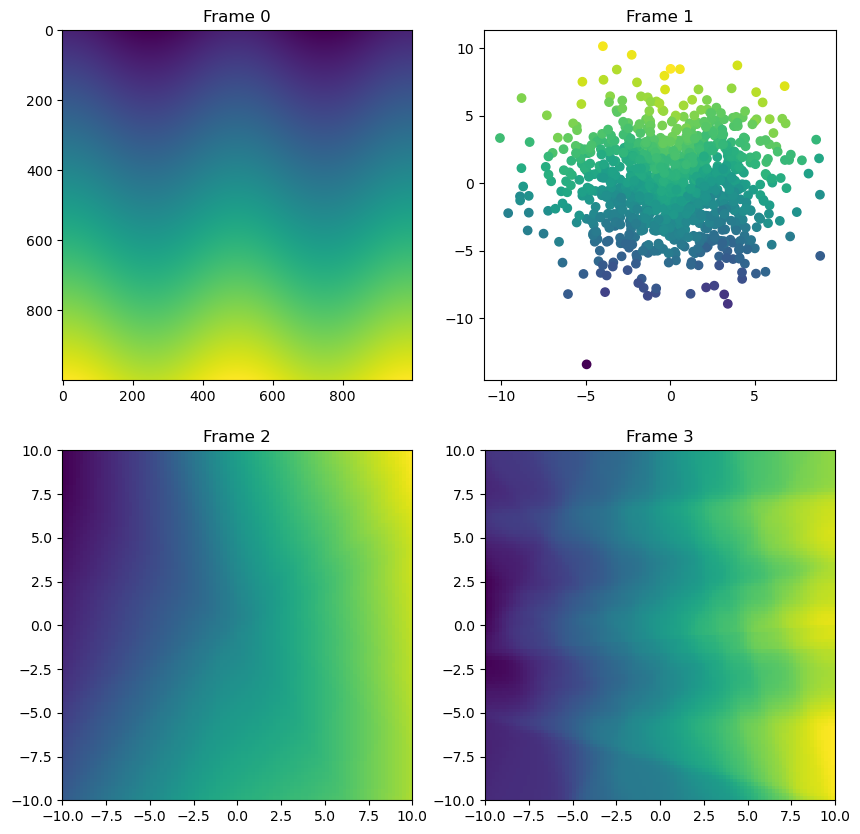

In [12]:
fig, ax = plt.subplots(2, 2, figsize=(10,10))
ax[0,0].imshow(new_data.pattern)
ax[0,1].scatter(new_data.x_values, new_data.y_values, c=new_data.color_values)

new_x = torch.linspace(-10, 10, 100)
grid_new = torch.stack(torch.meshgrid(new_x, new_x), dim=2)
output_new = model_new(grid_new).detach()
ax[1,0].imshow(output_new, extent=(-10, 10, -10, 10))

better_x = torch.linspace(-10, 10, 100)
grid_better = torch.stack(torch.meshgrid(better_x, better_x), dim=2)
output_better = model_better(grid_better).detach()
ax[1,1].imshow(output_better, extent=(-10, 10, -10, 10))


#loop through subplots
for i, ax in enumerate(ax.flat):
    ax.set_title(f"Frame {i}")
    print(i)


plt.show